In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
from matplotlib.patches import FancyArrowPatch
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

fsize = 9
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": fsize,
    "axes.titlesize": fsize,
    "axes.labelsize": fsize,
    "xtick.labelsize": fsize,
    "ytick.labelsize": fsize,
    "legend.fontsize": fsize,
})

def blob(pos, scale=1, phase=0, a = 0.15, b = 0.10, c = 0.07, resolution = 720):
    theta = np.linspace(0,2*np.pi,resolution)
    r = scale * (
        1
        + a * np.sin(2*theta + phase)
        + b * np.cos(3*theta - phase)
        + c * np.sin(5*theta + 0.5*phase)
    )
    return r*np.cos(theta) + pos[0], r*np.sin(theta) + pos[1]

def draw_axis(
    pos,
    axisname=None,
    azimuth=0,
    elevation=30,
    axislen=1,
    labeldist=1.3
):

    # Degrees -> radians
    azimuth = np.deg2rad(azimuth)
    elevation = np.deg2rad(elevation)

    # Original 3D Cartesian basis
    axes3d = np.array([
        [1, 0, 0],   # x
        [0, 1, 0],   # y
        [0, 0, 1]    # z
    ])

    # Orthographic projection

    azimuth_transform = np.array([
        [np.cos(azimuth), -np.sin(azimuth), 0],
        [np.sin(azimuth),  np.cos(azimuth), 0],
        [ 0             ,  0              , 1]
    ])

    elevation_transform = np.array([
        [1, 0                ,  0               ],
        [0, np.cos(elevation), -np.sin(elevation)],
        [0, np.sin(elevation),  np.cos(elevation)]
    ])

    drop_y = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    P = drop_y @ elevation_transform @ azimuth_transform 
    # Project 3D basis -> 2D
    axes2d = P @ axes3d 
    # Labels
    if axisname is None:
        labels = [
            r'$\mathbf{1}$',
            r'$\mathbf{2}$',
            r'$\mathbf{n}$'
        ]
    else:
        labels = axisname

    for ax, label in zip(axes2d.T, labels):

        plt.arrow(
            *pos,
            axislen * ax[0],
            axislen * ax[1],
            color='k',
            linewidth=1,
            head_width=0.05,
            head_length=0.1,
            length_includes_head=True
        )

        plt.annotate(
            label,
            [
                pos[0] + labeldist * axislen * ax[0],
                pos[1] + labeldist * axislen * ax[1]
            ],
            ha='center',
            va='center'
        )

def map_arrow(pt1, pt2, pt3, maplabel,
              label1gap=0.3, label2gap=0.3, mapgap=0.3,
              lw=0.75, head_width=0.05, head_length=0.1):

    def circle_from_3pts(p1, p2, p3):

        cross = ((p2[0] - p1[0]) * (p3[1] - p1[1])
               - (p2[1] - p1[1]) * (p3[0] - p1[0]))

        if abs(cross) < 1e-12:
            return None, None

        x1, y1 = p1
        x2, y2 = p2
        x3, y3 = p3

        D = 2 * (
            x1 * (y2 - y3)
            + x2 * (y3 - y1)
            + x3 * (y1 - y2)
        )

        Ux = (
            (x1**2 + y1**2) * (y2 - y3)
            + (x2**2 + y2**2) * (y3 - y1)
            + (x3**2 + y3**2) * (y1 - y2)
        ) / D

        Uy = (
            (x1**2 + y1**2) * (x3 - x2)
            + (x2**2 + y2**2) * (x1 - x3)
            + (x3**2 + y3**2) * (x2 - x1)
        ) / D

        center = np.array([Ux, Uy])
        radius = np.linalg.norm(p1 - center)

        return center, radius

    center, radius = circle_from_3pts(pt1, pt2, pt3)

    # ------------------------------------------------------------
    # Collinear case
    # ------------------------------------------------------------
    if center is None:

        v1 = pt2 - pt1
        v1 /= np.linalg.norm(v1)

        v2 = pt3 - pt2
        v2 /= np.linalg.norm(v2)

        start1 = pt1 + label1gap * v1
        end1   = pt2 - mapgap * v1

        start2 = pt2 + mapgap * v2
        end2   = pt3 - label2gap * v2

        plt.plot(
            [start1[0], end1[0]],
            [start1[1], end1[1]],
            'k-', lw=lw
        )

        plt.plot(
            [start2[0], end2[0]],
            [start2[1], end2[1]],
            'k-', lw=lw
        )

        for start, end in [(start1, end1), (start2, end2)]:
            dx = end[0] - start[0]
            dy = end[1] - start[1]

            plt.arrow(
                start[0], start[1],
                dx, dy,
                head_width=head_width,
                head_length=head_length,
                fc='k',
                ec='k',
                length_includes_head=True
            )

        plt.annotate(
            maplabel,
            pt2,
            ha='center',
            va='center',
            fontsize=12,
            fontweight='bold'
        )
        return

    # ------------------------------------------------------------
    # Angles
    # ------------------------------------------------------------
    def angle(pt):
        return np.arctan2(
            pt[1] - center[1],
            pt[0] - center[0]
        )

    theta1 = angle(pt1)
    theta2 = angle(pt2)
    theta3 = angle(pt3)

    # ------------------------------------------------------------
    # Positive CCW angular distance
    # ------------------------------------------------------------
    def ccw_dist(a, b):
        return (b - a) % (2 * np.pi)

    d12 = ccw_dist(theta1, theta2)
    d13 = ccw_dist(theta1, theta3)

    # ------------------------------------------------------------
    # Determine which pt1 -> pt3 arc contains pt2
    # ------------------------------------------------------------
    if d12 < d13:

        t1 = theta1
        t2 = theta1 + d12
        t3 = theta1 + d13

        direction = 1

    else:

        t1 = theta1
        t2 = theta1 - ccw_dist(theta2, theta1)
        t3 = theta1 - ccw_dist(theta3, theta1)

        direction = -1

    # ------------------------------------------------------------
    # Convert requested linear gaps to angular gaps
    # ------------------------------------------------------------
    gap1 = label1gap / radius
    gap2 = label2gap / radius
    gapm = mapgap / radius

    # ------------------------------------------------------------
    # Split the selected arc into two pieces
    # ------------------------------------------------------------
    if direction == 1:

        arc1_start = t1 + gap1
        arc1_end   = t2 - gapm

        arc2_start = t2 + gapm
        arc2_end   = t3 - gap2

    else:

        arc1_start = t1 - gap1
        arc1_end   = t2 + gapm

        arc2_start = t2 - gapm
        arc2_end   = t3 + gap2

    # ------------------------------------------------------------
    # Generate circular arc
    # ------------------------------------------------------------
    def make_arc(a, b, n=200):

        theta = np.linspace(a, b, n)

        x = center[0] + radius * np.cos(theta)
        y = center[1] + radius * np.sin(theta)

        return x, y

    x1, y1 = make_arc(arc1_start, arc1_end)
    x2, y2 = make_arc(arc2_start, arc2_end)

    # ------------------------------------------------------------
    # Draw arcs
    # ------------------------------------------------------------
    plt.plot(x1, y1, 'k-', lw=lw)
    plt.plot(x2, y2, 'k-', lw=lw)

    # ------------------------------------------------------------
    # Actual plt.arrow at the END of each arc
    # ------------------------------------------------------------
    def add_arrow(x, y):

        i = 10

        x0 = x[-i]
        y0 = y[-i]

        x1 = x[-1]
        y1 = y[-1]

        dx = x1 - x0
        dy = y1 - y0

        plt.arrow(
            x0,
            y0,
            dx,
            dy,
            head_width=head_width,
            head_length=head_length,
            fc='k',
            ec='k',
            length_includes_head=True,
            zorder=5
        )

    add_arrow(x1, y1)
    add_arrow(x2, y2)

    # ------------------------------------------------------------
    # Label at pt2
    # ------------------------------------------------------------
    plt.annotate(
        maplabel,
        pt2,
        ha='center',
        va='center',
        fontweight='bold'
    )

def projection2d(azimuth, elevation): 
    azimuth = np.deg2rad(azimuth)
    elevation = np.deg2rad(elevation)

    azimuth_transform = np.array([
        [np.cos(azimuth), -np.sin(azimuth), 0],
        [np.sin(azimuth),  np.cos(azimuth), 0],
        [ 0             ,  0              , 1]
    ])

    elevation_transform = np.array([
        [1, 0                ,  0               ],
        [0, np.cos(elevation), -np.sin(elevation)],
        [0, np.sin(elevation),  np.cos(elevation)]
    ])

    drop_y = np.array([
        [1, 0, 0],
        [0, 0, 1]
    ])

    P = drop_y @ elevation_transform @ azimuth_transform 
    return P


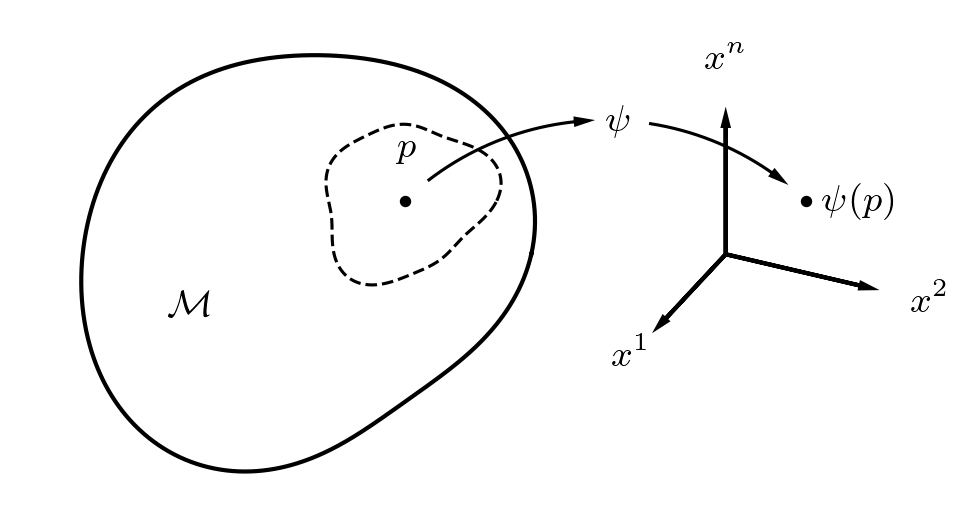

In [207]:
figname = r'..\images\psimapping.pdf'
plt.figure(figsize=(4,2),dpi = 300)
plt.gca().set_aspect('equal')

u, v = blob(np.array([0,0]),2,0.5,0.1,0.05,0)
plt.plot(u,v, 'k-',lw=1)

p = np.array([1,0.5])
u, v = blob(p,0.75,0.5,0.1,0.1,0.05)
plt.plot(u,v, 'k--',lw=0.75)
plt.scatter(*p, color='k',s=3)

axis_pos = [4,0]

fp = np.array([4.75,0.5])
plt.scatter(*fp, color='k',s=3)

draw_axis(axis_pos, ['$x^1$', '$x^2$', '$x^n$'],
          elevation = 30, azimuth = -115, 
          axislen = 1.5, labeldist = 1.4)

psi_pos = np.array([3,1.25])

plt.annotate(
    r'$p$',
    p + np.array([0,0.5]),
    ha='center',
    va='center'
)
plt.annotate(
    r'$\psi(p)$',
    fp + np.array([0.5,0]),
    ha='center',
    va='center'
)

map_arrow(
    p, psi_pos, fp, r'$\psi$'
)

plt.annotate(
    r'$\mathcal{M}$',
    np.array([-1,-0.5]),
    ha='center',
    va='center'
)

plt.tight_layout()
plt.xlim(-2.5,6)
plt.ylim(-2.1,2.1)
plt.axis('off')
plt.savefig(figname)
plt.show()


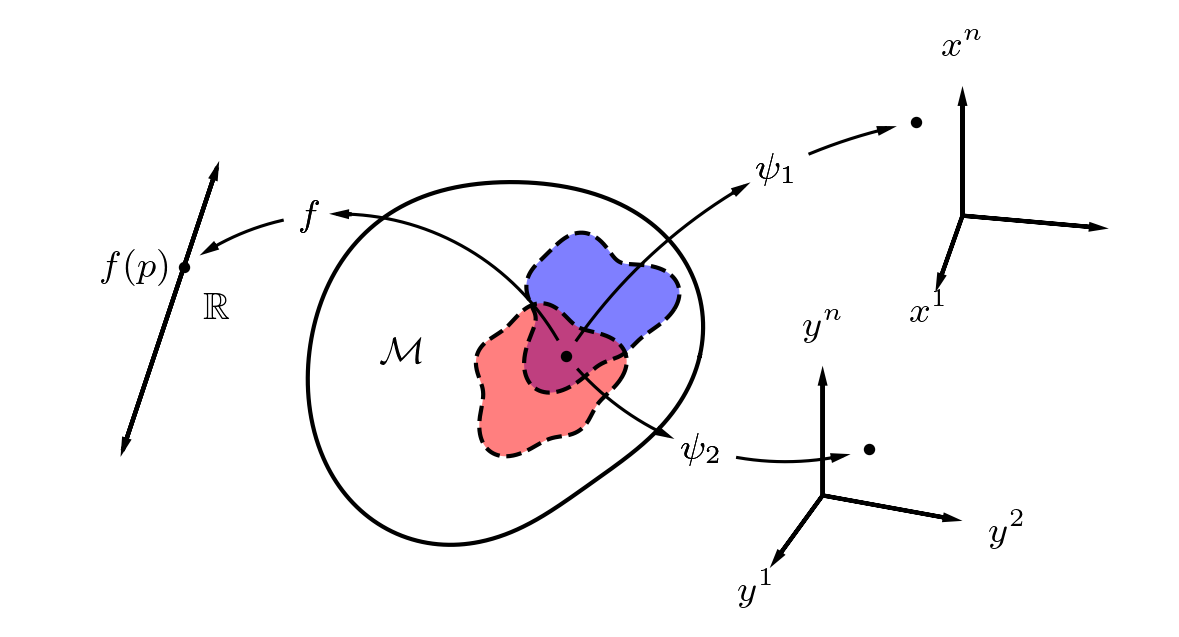

In [209]:
figname = r'..\images\twocharts.pdf'
plt.figure(figsize=(4,2.5),dpi = 300)
plt.gca().set_aspect('equal')

u, v = blob(np.array([0,0]),2,0.5,0.1,0.05,0)
plt.plot(u,v, 'k-',lw=1)


plt.tight_layout()

ax1pos = np.array([5, 1.5])
ax2pos = np.array([3.5,-1.5])

draw_axis(
    ax1pos,
    [
        r'$x^1$',
        r'$x^2$',
        r'$x^n$',
    ],
    azimuth = -100,
    elevation = 30,
    axislen = 1.5,
    labeldist = 1.4
)

draw_axis(
    ax2pos,
    [
        r'$y^1$',
        r'$y^2$',
        r'$y^n$',
    ],
    azimuth = -110,
    elevation = 30,
    axislen = 1.5,
    labeldist = 1.4
)


R0 = np.array([-4,-1])
Rf = np.array([-3, 2])

plt.arrow(
    *R0,
    *(Rf - R0),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.arrow(
    *Rf,
    *(R0 -Rf),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)

Rpos = (R0 + Rf)/2 + np.array([0.5,0])
plt.annotate(
    r'$\mathbb{R}$',
    Rpos,
    ha='center',
    va='center'
)

fp = R0 + 0.65 * (Rf - R0)
plt.scatter(*fp, c='k',s=3)


S1 = np.array([1,0.5])
S2 = np.array([0.5,-0.25])

u,v = blob(S1,0.75, 0.1, 0.1, 0.2, 0.1)
plt.plot(u,v,'k--',lw=1)
plt.fill(
    u,v,
    facecolor = 'b',
    edgecolor= None,
    alpha = 0.5
)
u,v = blob(S2,0.75, 0.1, 0.1, 0.1, 0.1)
plt.plot(u,v,'k--',lw=1)
plt.fill(
    u,v,
    facecolor = 'r',
    edgecolor= None,
    alpha = 0.5
)

p = np.array([0.75,0])
fp1 = ax1pos + np.array([-0.5,1])
fp2 = ax2pos + np.array([0.5,0.5])
plt.scatter(*fp1, c='k',s=3)
plt.scatter(*fp2, c='k',s=3)
plt.scatter(*p, c='k',s=3)
fpos = np.array([-2,1.5])
psi1pos = np.array([3,2])
psi2pos = np.array([2.2,-1])

plt.annotate(
    r'$f$',
    fpos,
    ha='center',
    va='center'
)
plt.annotate(
    r'$\psi_1$',
    psi1pos,
    ha='center',
    va='center'
)
plt.annotate(
    r'$\psi_2$',
    psi2pos,
    ha='center',
    va='center'
)
plt.annotate(
    r'$f(p)$',
    fp + np.array([-0.5,0]),
    ha='center',
    va='center'
)

plt.annotate(
    r'$\mathcal{M}$',
    p + np.array([-1.75,0]),
    ha='center',
    va='center'
)

map_arrow(p, fpos, fp, r'$f$', label1gap = 0.2)
map_arrow(p, psi1pos, fp1, r'$\psi_1$', label1gap = 0.2, mapgap = 0.4)
map_arrow(p, psi2pos, fp2, r'$\psi_2$', label1gap = 0.2, mapgap = 0.4)



plt.axis('off')
# plt.grid()
plt.xlim(-5,7)
plt.ylim(-2.5,3.4)
plt.tight_layout()
plt.savefig(figname)
plt.show()


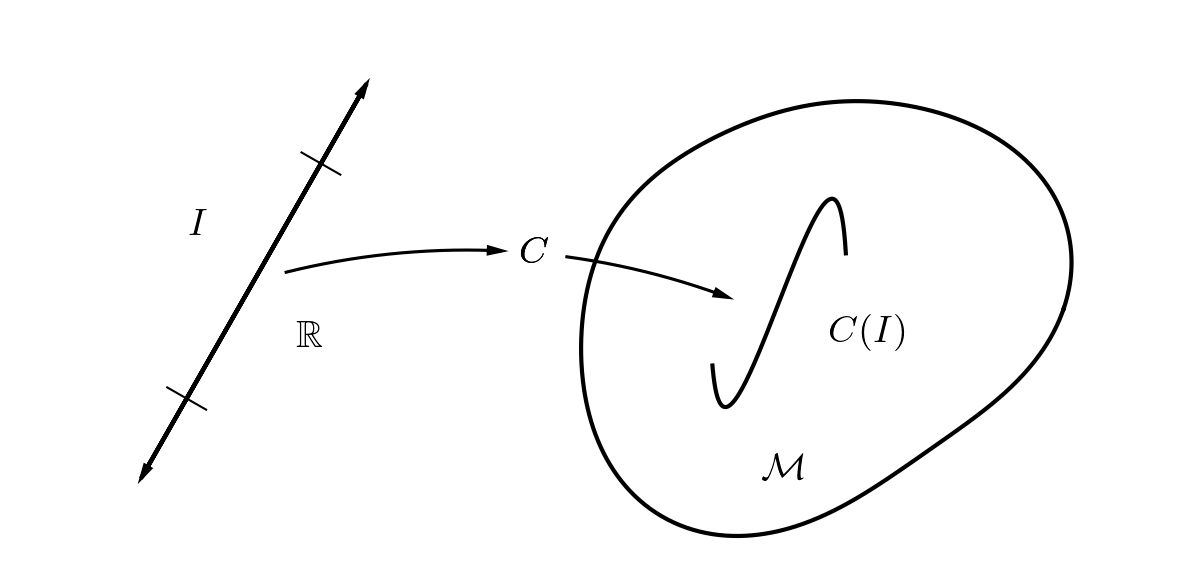

In [212]:
figname = r'..\images\curve_in_a_manifold.pdf'
plt.figure(figsize=(4,2),dpi = 300)
plt.gca().set_aspect('equal')

u, v = blob(np.array([2,0]),2,0.5,0.15,0.05,0.01)
plt.plot(u,v, 'k-',lw=1)





R0 = np.array([-4, -1.5])
Rf = np.array([-2, 2])

# Line direction (unit vector)
line = (Rf - R0)
line /= np.linalg.norm(line)

# Perpendicular tick direction (unit vector)
tick = np.array([line[1], -line[0]]) * 0.2  # length 0.2

# Positions of ticks along the line
tick1_pos = R0 + (Rf - R0) * 0.2
tick2_pos = R0 + (Rf - R0) * 0.8

# Plot ticks as lines
plt.plot(
    [tick1_pos[0] - tick[0], tick1_pos[0] + tick[0]],  # x coordinates
    [tick1_pos[1] - tick[1], tick1_pos[1] + tick[1]],  # y coordinates
    'k-', lw=0.5
)
plt.plot(
    [tick2_pos[0] - tick[0], tick2_pos[0] + tick[0]],
    [tick2_pos[1] - tick[1], tick2_pos[1] + tick[1]],
    'k-', lw=0.5
)

plt.arrow(
    *R0,
    *(Rf - R0),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.arrow(
    *Rf,
    *(R0 -Rf),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)

Rpos = (R0 + Rf)/2 + np.array([0.5,-0.5])
plt.annotate(
    r'$\mathbb{R}$',
    Rpos,
    ha='center',
    va='center'
)

Ipos = (R0 + Rf)/2 + np.array([-0.5,0.5])
plt.annotate(
    r'$I$',
    Ipos,
    ha='center',
    va='center'
)

Cpos = np.array([-0.5,0.5])
plt.annotate(
    r'$C$',
    Cpos,
    ha='center',
    va='center'
)
CIpos = np.array([2.5,-0.2])
plt.annotate(
    r'$C(I)$',
    CIpos,
    ha='center',
    va='center'
)

theta = np.deg2rad(80)
Rmat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
t = np.linspace(-1,4,600)
curve = np.array(
    [np.cos(t),
     0.2 * t]
)
curve = Rmat @ curve + np.array([[2],[0]])

map_arrow((R0 + Rf)/2, Cpos, [1.5,0], r'$C$')

plt.plot(curve[0],curve[1],'k-',lw=1)

plt.annotate(
    r'$\mathcal{M}$',
    CIpos + np.array([-0.75,-1.25]),
    ha='center',
    va='center'
)

plt.axis('off')
# plt.grid()
plt.xlim(-5,5)
plt.ylim(-2.1,2.5)
plt.tight_layout()
plt.savefig(figname)
plt.show()
 

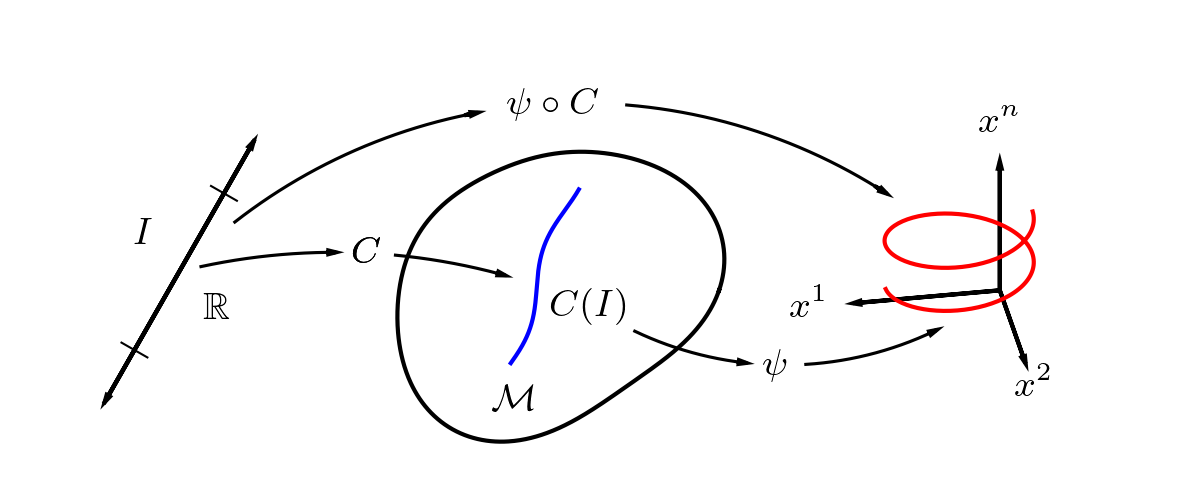

In [265]:
figname = r'..\images\curves-chart.pdf'
plt.figure(figsize=(4,2),dpi = 300)
plt.gca().set_aspect('equal')

u, v = blob(np.array([2,0]),2,0.5,0.15,0.05,0.01)
plt.plot(u,v, 'k-',lw=1)





R0 = np.array([-4, -1.5])
Rf = np.array([-2, 2])

# Line direction (unit vector)
line = (Rf - R0)
line /= np.linalg.norm(line)

# Perpendicular tick direction (unit vector)
tick = np.array([line[1], -line[0]]) * 0.2  # length 0.2

# Positions of ticks along the line
tick1_pos = R0 + (Rf - R0) * 0.2
tick2_pos = R0 + (Rf - R0) * 0.8

# Plot ticks as lines
plt.plot(
    [tick1_pos[0] - tick[0], tick1_pos[0] + tick[0]],  # x coordinates
    [tick1_pos[1] - tick[1], tick1_pos[1] + tick[1]],  # y coordinates
    'k-', lw=0.5
)
plt.plot(
    [tick2_pos[0] - tick[0], tick2_pos[0] + tick[0]],
    [tick2_pos[1] - tick[1], tick2_pos[1] + tick[1]],
    'k-', lw=0.5
)

plt.arrow(
    *R0,
    *(Rf - R0),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)
plt.arrow(
    *Rf,
    *(R0 -Rf),
    color='k',
    linewidth=1,
    head_width=0.05,
    head_length=0.1,
    length_includes_head=True
)

Rpos = (R0 + Rf)/2 + np.array([0.5,-0.5])
plt.annotate(
    r'$\mathbb{R}$',
    Rpos,
    ha='center',
    va='center'
)

Ipos = (R0 + Rf)/2 + np.array([-0.5,0.5])
plt.annotate(
    r'$I$',
    Ipos,
    ha='center',
    va='center'
)

Cpos = np.array([-0.5,0.5])
plt.annotate(
    r'$C$',
    Cpos,
    ha='center',
    va='center'
)
CIpos = np.array([2.5,-0.2])
plt.annotate(
    r'$C(I)$',
    CIpos,
    ha='center',
    va='center'
)

theta = np.deg2rad(-20)
Rmat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
t = np.linspace(-1,4,600)
curve = np.array(
    [0.1 * np.cos(1.4* t),
    0.5* t]
)
curve = Rmat @ curve + np.array([[1.6],[-0.5]])

map_arrow((R0 + Rf)/2, Cpos, CIpos, r'$C$', label1gap = 0.3,mapgap = 0.4, label2gap = 1.2)

plt.plot(curve[0],curve[1],'b-',lw=1)

axispos = np.array([8,0])
draw_axis(
    axispos,
    [
        r'$x^1$',
        r'$x^2$',
        r'$x^n$',
    ],
    azimuth = -170,
    elevation = 30,
    axislen = 2,
)

t = np.linspace(0,1,200)
curve = np.array([
    np.cos(3*np.pi * t) + 0.5,
    np.sin(3*np.pi * t) - 0.3,
    t
])



curve = projection2d(-170, 30) @ curve + axispos.reshape(2,1)

plt.plot(curve[0], curve[1], 'r-', lw=1)
psipos = np.array([5,-1])

map_arrow(CIpos, psipos, axispos, r'$\psi$', label1gap = 0.7,mapgap = 0.4, label2gap = 1)

psi_C_pos = np.array([2,2.5])
map_arrow((R0 + Rf)/2, psi_C_pos, axispos, r'$\psi\circ C$', label1gap = 1,mapgap = 1, label2gap = 2)

plt.annotate(
    r'$\mathcal{M}$',
    CIpos + np.array([-1,-1.3]),
    ha='center',
    va='center'
)

plt.axis('off')
# plt.grid()
plt.xlim(-5,10)
plt.ylim(-2.1,3.5)
plt.tight_layout()
plt.savefig(figname)
plt.show()
 

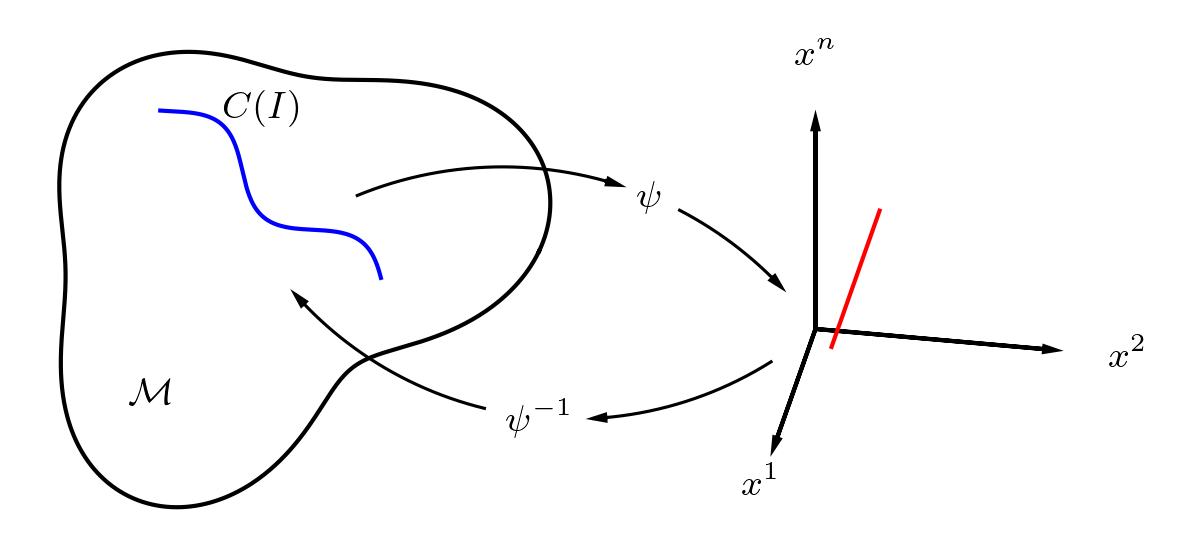

In [316]:
figname = r'..\images\specialcurves.pdf'
plt.figure(figsize=(4,2),dpi = 300)
plt.gca().set_aspect('equal')

M = np.array([0,0])
u, v = blob(M,2,0.5,0.15,0.2,0.01)
plt.plot(u,v, 'k-',lw=1)

axispos = np.array([5,-0.7])
draw_axis(
    axispos,
    [
        r'$x^1$',
        r'$x^2$',
        r'$x^n$'
    ],
    elevation = 30,
    azimuth = -100,
    axislen = 2.2
)

t = np.linspace(-0.5, 2, 200)
x1line = np.array([
    t,
    0*t + 0.5,
    0*t + 1
])

xline_proj = projection2d(-100,30) @ x1line + axispos.reshape(2,1)
plt.plot(xline_proj[0],xline_proj[1], 'r-', lw = 1)

curve = np.array([
    t,
    0.2*np.cos(1.2*np.pi * t)
]) 
theta = np.deg2rad(-40)
Rmat = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
curve = Rmat @ curve
curve += M.reshape(2,1) + np.array([[-0.5],[1]])
plt.plot(curve[0],curve[1],'b-',lw=1)

Cpos = np.array([3.5,0.5])
Cinvpos = np.array([2.5,-1.5])

map_arrow(M, Cpos, axispos, r'$\psi$',label1gap = 1, label2gap = 0.5)
map_arrow(axispos, Cinvpos, M, r'$\psi^{-1}$',label2gap = 0.5, label1gap = 0.5, mapgap = 0.5)
plt.xlim(-2.1,8)
# plt.ylim(-2.1,3.5)

plt.axis('off')
# plt.grid()

plt.annotate(
    r'$\mathcal{M}$',
    M + np.array([-1,-1.3]),
    ha='center',
    va='center'
)

plt.annotate(
    r'$C(I)$',
    M + np.array([0,1.3]),
    ha='center',
    va='center'
)

plt.tight_layout()
plt.savefig(figname)
plt.show()


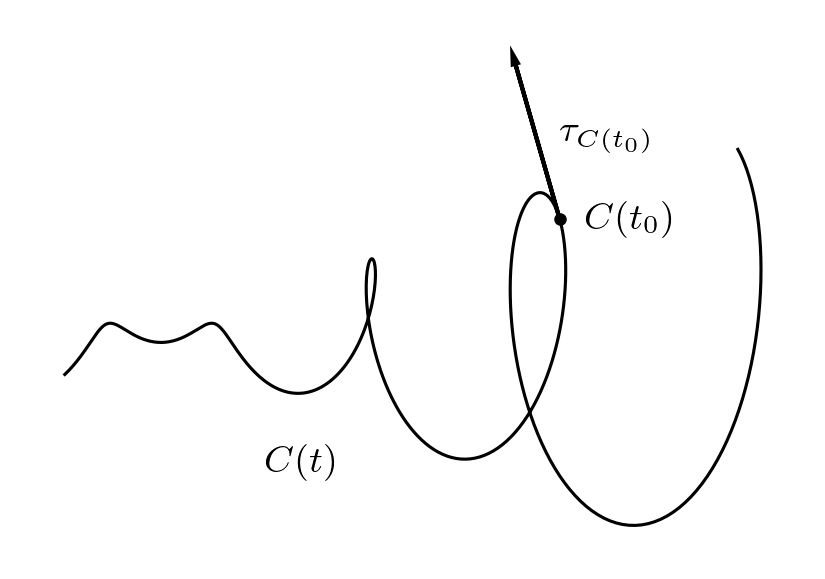

In [312]:
figname = r'..\images\tangentvectors.pdf'

plt.figure(figsize=(4,2), dpi=300)

plt.gca().set_aspect('equal')

t = np.linspace(-2, 10, 400)
dt = 1e-6 

def crv(t):
    f =  np.array([
                t,
                0.2* t * np.cos(2*t),
                0.3* t * np.sin(2*t)
            ])
    return f

curve = crv(t)
tp = 6.8
p = crv(tp)

v = ( crv(tp + dt) - crv(tp - dt))/ (2 * dt)



curve_prj = projection2d(-40, 0) @ curve
p_prj = projection2d(-40, 0) @ p
v_prj = projection2d(-40, 0) @ v
plt.plot(curve_prj[0], curve_prj[1], 'k-', lw= 0.75)
plt.scatter(*p_prj, c='k',s = 4)

plt.arrow(*p_prj, *v_prj,
            color='k',
            linewidth=1,
            head_width=0.075,
            head_length=0.15,
            length_includes_head=True)


plt.annotate(
    r'$C(t)$',
    np.array([2,-1.7]),
    ha='center',
    va='center'
)

plt.annotate(
    r'$C(t_0)$',
    p_prj + np.array([1,0]),
    ha='center',
    va='center'
)

plt.annotate(
    r'$\tau_{C(t_0)}$',
    p_prj + (v_prj)/2 + np.array([1,0]),
    ha='center',
    va='center'
)
plt.axis('off')

plt.tight_layout()

plt.savefig(figname)

plt.show()